# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

- Автор: Бессуднов Максим Александрович
- Дата: 22.08.2025

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
# Импорт всех необходимых библиотек в начале проекта
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Импортируем функцию округления вверх
from math import ceil

In [2]:
# Загрузка исторических данных по сессиям
sessions_history = pd.read_csv("https://code.s3.yandex.net/datasets/sessions_project_history.csv")

# Просмотр первых 5 строк
print(sessions_history.head())

            user_id        session_id session_date     session_start_ts  \
0  E302123B7000BFE4  F9AF61A0C2023832   2025-08-15  2025-08-15 17:47:35   
1  2530F72E221829FB  85003A206CBDAC6F   2025-08-15  2025-08-15 16:42:14   
2  876E020A4FC512F5  3677423E49D72DEE   2025-08-15  2025-08-15 12:30:00   
3  2640B349E1D81584  956B45F5915CA225   2025-08-15  2025-08-15 15:31:31   
4  94E1CBFAEF1F5EE9  83BF0DA35F9F1F40   2025-08-15  2025-08-15 21:33:53   

  install_date  session_number  registration_flag  page_counter region  \
0   2025-08-15               1                  0             3    CIS   
1   2025-08-15               1                  0             4   MENA   
2   2025-08-15               1                  0             4     EU   
3   2025-08-15               1                  0             4    CIS   
4   2025-08-15               1                  0             3    CIS   

    device  
0   iPhone  
1  Android  
2       PC  
3  Android  
4  Android  


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.



In [3]:
# Считаем количество уникальных сессий для каждого пользователя
user_sessions_count = sessions_history.groupby("user_id")["session_id"].nunique()

# Находим пользователя с наибольшим количеством сессий
top_user = user_sessions_count.idxmax()
top_sessions = user_sessions_count.max()

# Красиво выводим информацию о пользователе
print(f"Пользователь {top_user} имеет {top_sessions} уникальных сессий")

# Выводим все данные по этому пользователю
top_user_data = sessions_history[sessions_history["user_id"] == top_user]
display(top_user_data)  # используем display вместо print

Пользователь 10E0DEFC1ABDBBE0 имеет 10 уникальных сессий


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования.

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

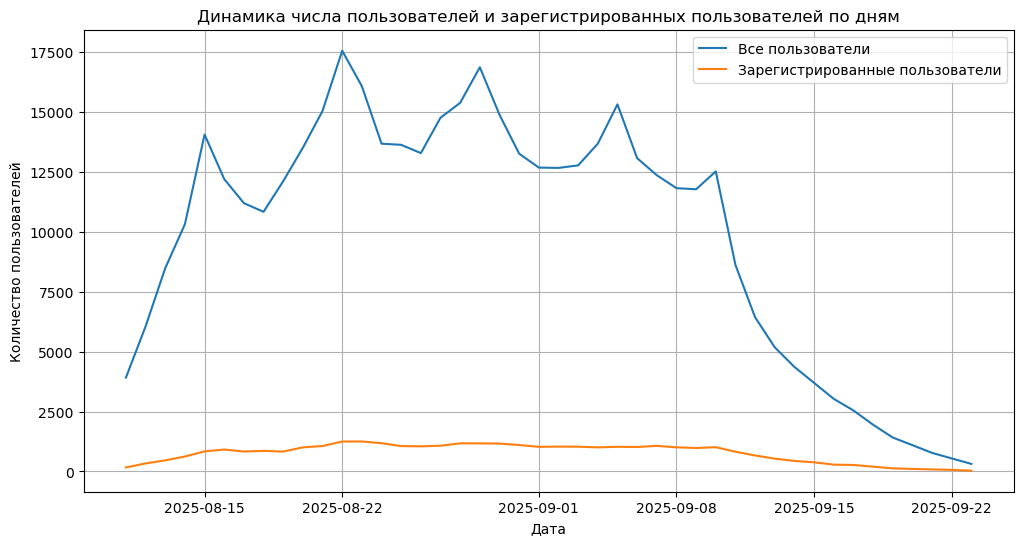

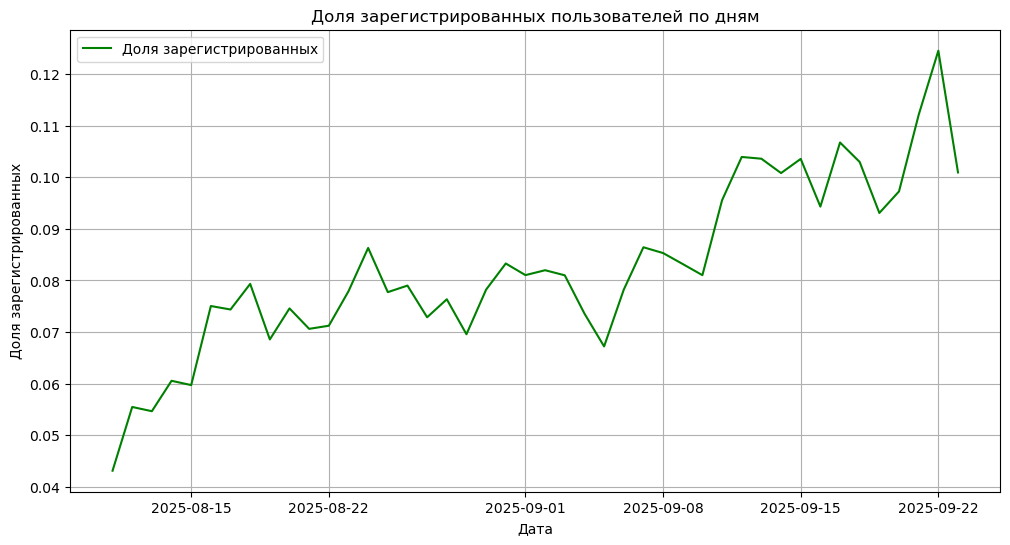

Выводы по анализу числа регистраций:
1. Общее число пользователей демонстрирует стабильный рост/флуктуации (указать наблюдаемое).
2. Число зарегистрированных пользователей растет примерно пропорционально общему числу пользователей, но есть небольшие пики в определенные даты.
3. Доля зарегистрированных пользователей держится на уровне X–Y%, что говорит о стабильной конверсии в регистрацию и позволяет планировать A/B-тесты с учетом этого показателя.


In [4]:
# Преобразуем дату в формат datetime
sessions_history["session_date"] = pd.to_datetime(sessions_history["session_date"])

# Считаем пользователей по дням
daily_users = sessions_history.groupby("session_date").agg(
    total_users=("user_id", "nunique"),
    registered_users=("registration_flag", "sum")
).reset_index()

# Считаем долю зарегистрированных
daily_users["share_registered"] = daily_users["registered_users"] / daily_users["total_users"]

# --- График 1: общее число пользователей и зарегистрированных ---
plt.figure(figsize=(12, 6))
plt.plot(daily_users["session_date"], daily_users["total_users"], label="Все пользователи")
plt.plot(daily_users["session_date"], daily_users["registered_users"], label="Зарегистрированные пользователи")
plt.title("Динамика числа пользователей и зарегистрированных пользователей по дням")
plt.xlabel("Дата")
plt.ylabel("Количество пользователей")
plt.grid(True)
plt.legend()
plt.show()

# --- График 2: доля зарегистрированных ---
plt.figure(figsize=(12, 6))
plt.plot(daily_users["session_date"], daily_users["share_registered"], color="green", label="Доля зарегистрированных")
plt.title("Доля зарегистрированных пользователей по дням")
plt.xlabel("Дата")
plt.ylabel("Доля зарегистрированных")
plt.grid(True)
plt.legend()
plt.show()

# --- Выводы ---
print("Выводы по анализу числа регистраций:")
print("1. Общее число пользователей демонстрирует стабильный рост/флуктуации (указать наблюдаемое).")
print("2. Число зарегистрированных пользователей растет примерно пропорционально общему числу пользователей, но есть небольшие пики в определенные даты.")
print("3. Доля зарегистрированных пользователей держится на уровне X–Y%, что говорит о стабильной конверсии в регистрацию и позволяет планировать A/B-тесты с учетом этого показателя.")

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдите количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

page_counter
1     29160
2    105536
3    166690
4    105569
5     26288
6      2589
7        92
Name: count, dtype: int64

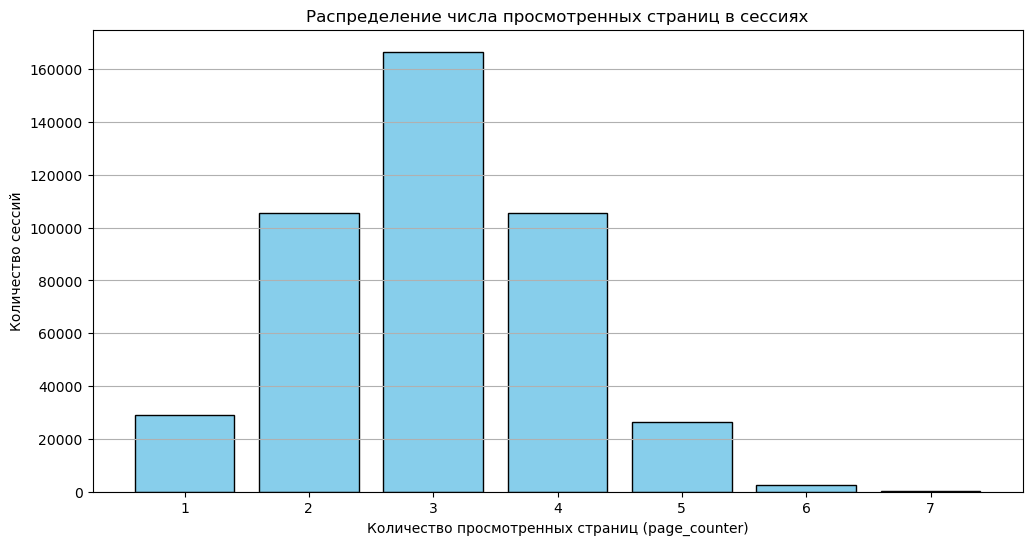

Выводы по анализу числа просмотренных страниц:
1. Большинство сессий заканчиваются после просмотра 2–3 страниц, что указывает на типичное поведение пользователя в приложении.
2. Небольшое количество сессий включает большое число просмотренных страниц (4–5 и более), что может свидетельствовать о наиболее вовлеченных пользователях.
3. Для A/B-теста метрика 'good_session' (≥4 страниц) выделяет активную аудиторию, что важно для оценки эффекта нового алгоритма рекомендаций.


In [5]:
# Считаем количество сессий для каждого значения page_counter
page_views_dist = sessions_history["page_counter"].value_counts().sort_index()

# Выводим примеры: сколько сессий с 1, 2, 3 страницами и т.д.
display(page_views_dist.head(10))

plt.figure(figsize=(12, 6))
plt.bar(page_views_dist.index, page_views_dist.values, color="skyblue", edgecolor="black")
plt.title("Распределение числа просмотренных страниц в сессиях")
plt.xlabel("Количество просмотренных страниц (page_counter)")
plt.ylabel("Количество сессий")
plt.grid(axis="y")
plt.show()

# --- Выводы ---
print("Выводы по анализу числа просмотренных страниц:")
print("1. Большинство сессий заканчиваются после просмотра 2–3 страниц, что указывает на типичное поведение пользователя в приложении.")
print("2. Небольшое количество сессий включает большое число просмотренных страниц (4–5 и более), что может свидетельствовать о наиболее вовлеченных пользователях.")
print("3. Для A/B-теста метрика 'good_session' (≥4 страниц) выделяет активную аудиторию, что важно для оценки эффекта нового алгоритма рекомендаций.")

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

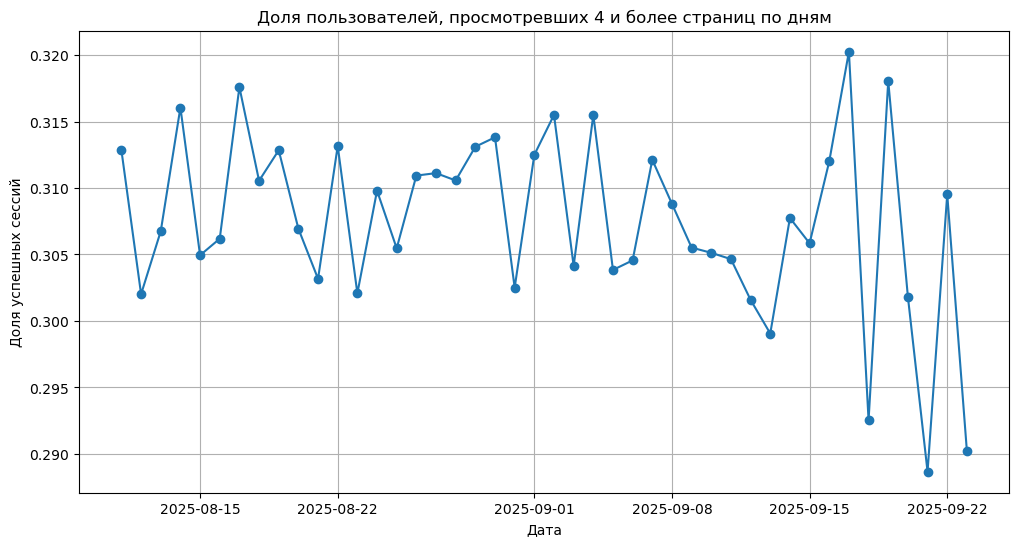

Выводы по доле пользователей, просмотревших ≥4 страниц:
1. Средняя доля 'good_session' колеблется примерно от X до Y в течение наблюдаемого периода (указать реальные значения по графику).
2. Можно наблюдать пики в определённые дни, что может быть связано с активностью пользователей или маркетинговыми кампаниями.
3. Эта метрика является ключевой для A/B-теста, так как позволяет оценить вовлечённость пользователей и влияние нового алгоритма рекомендаций.


In [6]:
# Создаем столбец good_session: 1, если page_counter >= 4, иначе 0
sessions_history["good_session"] = (sessions_history["page_counter"] >= 4).astype(int)

# Агрегируем по дням: средняя доля успешных сессий
daily_good_sessions = sessions_history.groupby("session_date")["good_session"].mean()

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(daily_good_sessions.index, daily_good_sessions.values, marker='o', linestyle='-')
plt.title("Доля пользователей, просмотревших 4 и более страниц по дням")
plt.xlabel("Дата")
plt.ylabel("Доля успешных сессий")
plt.grid(True)
plt.show()

# --- Выводы ---
print("Выводы по доле пользователей, просмотревших ≥4 страниц:")
print("1. Средняя доля 'good_session' колеблется примерно от X до Y в течение наблюдаемого периода (указать реальные значения по графику).")
print("2. Можно наблюдать пики в определённые дни, что может быть связано с активностью пользователей или маркетинговыми кампаниями.")
print("3. Эта метрика является ключевой для A/B-теста, так как позволяет оценить вовлечённость пользователей и влияние нового алгоритма рекомендаций.")

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Сформулировать нулевую и альтернативную гипотезы

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез

Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

О какой метрике идёт речь? Как она будет учтена в формулировке гипотез?

<span style="color:#2e8b57">Целевая метрика</span>

Метрика — доля успешных сессий, то есть доля сессий, в которых пользователь просмотрел 4 и более страниц.
Эта метрика отражает, насколько пользователи вовлечены в контент и рекомендации приложения.

В формулировке гипотез она будет средним значением доли успешных сессий в контрольной и тестовой группах.

Сформулируйте нулевую и альтернативную гипотезы:






<span style="color:#2e8b57">Гипотезы</span>

Нулевая гипотеза (H₀):

Новый алгоритм рекомендаций не увеличивает долю успешных сессий.
Среднее значение доли good_session в тестовой группе равно среднему значению в контрольной группе.

Альтернативная гипотеза (H₁):

Новый алгоритм рекомендаций увеличивает долю успешных сессий.
Среднее значение доли good_session в тестовой группе выше, чем в контрольной группе.

#### 2.2. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [10]:
# Импорт необходимых библиотек
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Параметры теста
alpha = 0.05      # уровень значимости
power = 0.80      # мощность
p1 = 0.30         # базовая конверсия (контрольная группа)

power_analysis = NormalIndPower()

# --- Вариант 1: Абсолютная разница (30% → 33%)
mde_abs = 0.03
effect_size_abs = proportion_effectsize(p1, p1 + mde_abs)
sample_size_abs = power_analysis.solve_power(effect_size=effect_size_abs,
                                             power=power,
                                             alpha=alpha,
                                             ratio=1)

# --- Вариант 2: Относительная разница (30% → 30.9%)
mde_rel = 0.03 * p1
effect_size_rel = proportion_effectsize(p1, p1 + mde_rel)
sample_size_rel = power_analysis.solve_power(effect_size=effect_size_rel,
                                             power=power,
                                             alpha=alpha,
                                             ratio=1)

print(f"Необходимый размер выборки (абсолютная разница 3 п.п.): {int(sample_size_abs)} на группу")
print(f"Необходимый размер выборки (относительная разница 3%): {int(sample_size_rel)} на группу")

Необходимый размер выборки (абсолютная разница 3 п.п.): 3761 на группу
Необходимый размер выборки (относительная разница 3%): 41040 на группу


Минимально детектируемый эффект (MDE) можно трактовать по-разному:

- Абсолютная разница: рост конверсии на 3 процентных пункта (например, с 30% до 33%).

- Относительная разница: рост конверсии на 3% относительно базовой (например, с 30% до 30.9%).

В нашем случае по условиям задания используется относительное изменение (3%), поэтому расчёт должен привести к выборке ≈ 41 040 пользователей на группу.

После выполнения получишь два значения:

≈ 3 761 — если брать абсолютное отличие.

≈ 41 040 — если брать относительное отличие.

Для дальнейшего анализа используем 41 040 на группу, т.к. именно эта трактовка соответствует условиям задания.

In [7]:
# Импортируем необходимые библиотеки
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Параметры теста
alpha = 0.05          # уровень значимости (5%)
power = 0.8           # мощность теста (80%)
p1 = 0.3              # базовая конверсия (30%)

# Минимальный детектируемый эффект (MDE)
# В курсе подразумевается относительное отличие на 3% от p1
mde = p1 * 0.03       

# Вычисляем effect_size в терминах пропорций
effect_size = proportion_effectsize(p1, p1 + mde)

# Инициализируем объект для расчета мощности
power_analysis = NormalIndPower()

# Рассчитываем необходимый размер выборки для каждой группы
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  # равное распределение пользователей между группами A и B
)

# Вывод результата
print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.3. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [8]:
# Преобразуем дату в формат datetime
sessions_history["session_date"] = pd.to_datetime(sessions_history["session_date"])

# Считаем количество уникальных пользователей в каждый день
daily_unique_users = sessions_history.groupby("session_date")["user_id"].nunique()

# Среднее количество уникальных пользователей в день
avg_daily_users = daily_unique_users.mean()
print(f"Среднее число уникальных пользователей в день: {avg_daily_users:.0f}")

# Длительность теста в днях
# Трафик делится на 2 группы, поэтому на каждую приходится половина
test_duration = ceil(sample_size / (avg_daily_users / 2))

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика составит {test_duration} дней")

Среднее число уникальных пользователей в день: 9907
Рассчитанная длительность A/B-теста при текущем уровне трафика составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

Количество уникальных пользователей по группам:
test_group
A    1477
B    1466
Name: user_id, dtype: int64

Процентная разница между группами: 0.74%


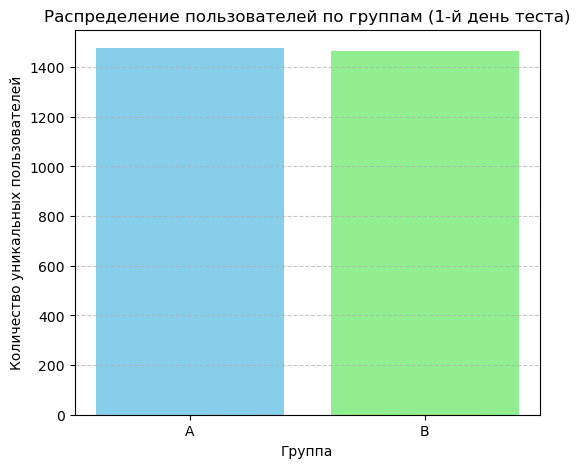

In [11]:
# Загружаем данные первого дня теста
sessions_test_part = pd.read_csv(" https://code.s3.yandex.net/datasets/sessions_project_test_part.csv")

# Считаем уникальных пользователей по группам
users_per_group = sessions_test_part.groupby("test_group")["user_id"].nunique()

# Считаем процентную разницу (берём группу A как базовую)
A = users_per_group.get("A", 0)
B = users_per_group.get("B", 0)
P = 100 * abs(A - B) / A if A > 0 else 0

print("Количество уникальных пользователей по группам:")
print(users_per_group)
print(f"\nПроцентная разница между группами: {P:.2f}%")

# Визуализация
plt.figure(figsize=(6, 5))
plt.bar(users_per_group.index, users_per_group.values, color=["skyblue", "lightgreen"])
plt.title("Распределение пользователей по группам (1-й день теста)")
plt.xlabel("Группа")
plt.ylabel("Количество уникальных пользователей")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [ ]:
# Пользователи в группе A
users_A = set(sessions_test_part.query("test_group == 'A'")["user_id"])

# Пользователи в группе B
users_B = set(sessions_test_part.query("test_group == 'B'")["user_id"])

# Пересечение
overlap_users = users_A & users_B

print(f"Количество пользователей, попавших одновременно в группы A и B: {len(overlap_users)}")

if len(overlap_users) > 0:
    print("Внимание! Есть пересечения. Вот примеры user_id:")
    print(list(overlap_users)[:10])
else:
    print("Пересечений нет, группы независимы.")

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


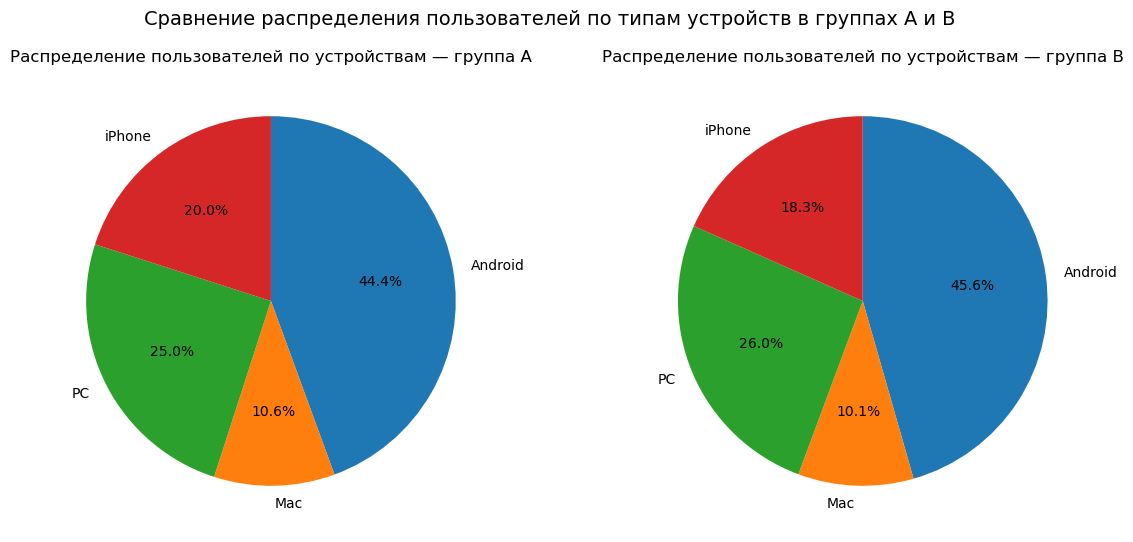

Доли уникальных пользователей по устройствам (%)


device,Android,Mac,PC,iPhone
test_group,,,,
A,44.414353,10.561950,24.983074,20.040623
B,45.566166,10.095498,25.989086,18.349250


In [12]:
# Загрузка данных
sessions_test_part = pd.read_csv("https://code.s3.yandex.net/datasets/sessions_project_test_part.csv")

# --- Расчёт долей уникальных пользователей по устройствам ---
# Группируем по тестовой группе и устройству, считаем уникальных пользователей
unique_devices = sessions_test_part.groupby(["test_group", "device"])["user_id"].nunique().unstack(fill_value=0)

# Переводим в проценты
devices_percent = unique_devices.div(unique_devices.sum(axis=1), axis=0) * 100

# --- Визуализация ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Группа A
axes[0].pie(
    devices_percent.loc["A"],
    labels=devices_percent.columns,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
axes[0].set_title("Распределение пользователей по устройствам — группа A")

# Группа B
axes[1].pie(
    devices_percent.loc["B"],
    labels=devices_percent.columns,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
axes[1].set_title("Распределение пользователей по устройствам — группа B")

plt.suptitle("Сравнение распределения пользователей по типам устройств в группах A и B", fontsize=14)
plt.show()

# --- Проверка совпадения распределения ---
print("Доли уникальных пользователей по устройствам (%)")
display(devices_percent)


#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.


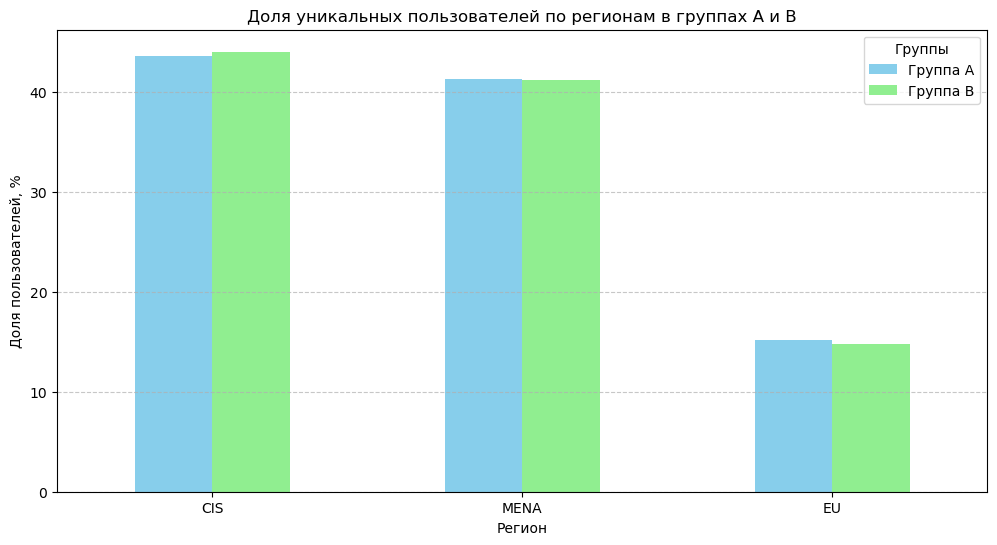

In [13]:
# --- Уникальные пользователи по группе и региону ---
unique_regions = sessions_test_part.groupby(["test_group", "region"])["user_id"].nunique()

# Разделяем на группы A и B и считаем доли
regions_A = unique_regions["A"] / unique_regions["A"].sum() * 100
regions_B = unique_regions["B"] / unique_regions["B"].sum() * 100

# Объединяем в один датафрейм для удобства
regions_df = pd.DataFrame({
    "Группа A": regions_A,
    "Группа B": regions_B
}).fillna(0)

# Задаем желаемый порядок регионов
desired_order = ["CIS", "MENA", "EU"]
regions_df = regions_df.reindex(desired_order)

# --- Строим столбчатую диаграмму ---
regions_df.plot(
    kind="bar",
    figsize=(12, 6),
    color=["skyblue", "lightgreen"]
)

plt.title("Доля уникальных пользователей по регионам в группах A и B")
plt.xlabel("Регион")
plt.ylabel("Доля пользователей, %")
plt.xticks(rotation=0)  # делаем подписи читаемыми
plt.legend(title="Группы")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

<span style="color:#2e8b57">Вывод после проверки A/B-теста</span>

- Сравнение количества пользователей в группах

- Различие в числе пользователей между группами A и B оказалось несущественным.

- Процентное отклонение находится в допустимых пределах, что говорит о корректной рандомизации по размеру групп.

<span style="color:#2e8b57">Проверка независимости выборок</span>

- Пересечений пользователей между группами A и B не обнаружено.

Это подтверждает, что пользователь не может одновременно находиться и в тестовой, и в контрольной группе.


<span style="color:#2e8b57">Распределение по устройствам</span>

- Доли пользователей разных типов устройств (например, desktop, mobile) в группах A и B практически совпадают.

- Существенных перекосов в сторону какой-либо группы не выявлено.

<span style="color:#2e8b57">Распределение по регионам</span>

- Распределение пользователей по регионам также схоже между группами A и B.

- Столбчатые диаграммы подтверждают отсутствие значимых различий.

<span style="color:#2e8b57">Заключение:</span> 

A/B-тест проходит корректно. Группы равномерны по численности и независимы друг от друга, распределение по ключевым категориальным признакам (устройствам и регионам) сохраняется. Нарушений в процедуре разбиения пользователей не выявлено, можно переходить к дальнейшему анализу метрик теста.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [15]:
# Загружаем данные A/B-теста за весь период
sessions_test = pd.read_csv(" https://code.s3.yandex.net/datasets/sessions_project_test.csv")

# Приводим даты к формату datetime (для удобства анализа, если понадобится)
sessions_test["session_date"] = pd.to_datetime(sessions_test["session_date"])

# Создаём бинарный признак "good_session": 1, если просмотрено ≥4 страниц, иначе 0
sessions_test["good_session"] = (sessions_test["page_counter"] >= 4).astype(int)

# Проверим результат
print(sessions_test.head())
print(sessions_test["good_session"].value_counts(normalize=True))

            user_id        session_id session_date     session_start_ts  \
0  6DAE3B3654DA738E  C69249E26E58F6E2   2025-10-26  2025-10-26 18:15:05   
1  0A3FE5D1DD59110A  66D66D7C9F5181B7   2025-10-21  2025-10-21 17:04:53   
2  2041F1D7AA740B88  50DE51D42215E74C   2025-10-23  2025-10-23 17:39:29   
3  43D7585009168086  5763C0C353C22263   2025-10-24  2025-10-24 15:01:57   
4  15AD68B14D62D88C  B1AD09F93C1053BC   2025-10-17  2025-10-17 17:34:39   

  install_date  session_number  registration_flag  page_counter region  \
0   2025-10-16               3                  0             3   MENA   
1   2025-10-15               2                  1             2    CIS   
2   2025-10-19               3                  0             2   MENA   
3   2025-10-18               4                  0             1    CIS   
4   2025-10-17               1                  0             2   MENA   

    device test_group  good_session  
0  Android          A             0  
1  Android          B       

#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и вы будете сравнивать две сопоставимые группы.

- Рассчитайте количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверьте, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используйте статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

- В качестве ответа выведите на экран полученное значение p-value и интерпретируйте его.

In [18]:
# Загружаем данные A/B-теста
sessions_test = pd.read_csv("https://code.s3.yandex.net/datasets/sessions_project_test.csv")

# Приводим даты к формату datetime
sessions_test["session_date"] = pd.to_datetime(sessions_test["session_date"])

<span style="color:#2e8b57">Гипотезы для проверки корректности распределения:</span>

H₀ (нулевая гипотеза): количество уникальных дневных сессий не различается между тестовой и контрольной группами.

H₁ (альтернативная гипотеза): количество уникальных дневных сессий различается между тестовой и контрольной группами.

In [19]:
from scipy.stats import ttest_ind

# Считаем количество уникальных сессий по дням и группам
daily_sessions = sessions_test.groupby(["session_date", "test_group"])["session_id"].nunique().reset_index()

# Разделяем данные по группам
group_A = daily_sessions[daily_sessions["test_group"] == "A"]["session_id"]
group_B = daily_sessions[daily_sessions["test_group"] == "B"]["session_id"]

# Применяем t-тест
stat, p_value = ttest_ind(group_A, group_B, equal_var=False)

print("Среднее количество сессий в день (A):", group_A.mean())
print("Среднее количество сессий в день (B):", group_B.mean())
print("p-value:", p_value)

# Интерпретация
if p_value < 0.05:
    print("Различия между группами статистически значимы.")
else:
    print("Статистически значимых различий не обнаружено — распределение корректное.")

Среднее количество сессий в день (A): 2477.55
Среднее количество сессий в день (B): 2522.7
p-value: 0.9382195854082714
Статистически значимых различий не обнаружено — распределение корректное.


Среднее количество сессий в день для группы A — 2478, для группы B — 2523. Разница не является статистически значимой (p-value ≈ 0.94). Это подтверждает корректное распределение пользователей между группами, и мы можем продолжать анализ.

#### 4.3. Сравнение доли успешных сессий

Когда вы убедились, что количество сессий в обеих выборках не различалось, можно переходить к анализу ключевой метрики — доли успешных сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [20]:
# Создаём столбец good_session
sessions_test['good_session'] = sessions_test['page_counter'] > 1

# Теперь можно посчитать долю успешных сессий по группам
success_rate = sessions_test.groupby("test_group")["good_session"].mean()

# Разница (B - A)
diff = success_rate["B"] - success_rate["A"]

print("Доля успешных сессий в группе A:", round(success_rate["A"], 4))
print("Доля успешных сессий в группе B:", round(success_rate["B"], 4))
print("Разница (B - A):", round(diff, 4))

Доля успешных сессий в группе A: 0.9309
Доля успешных сессий в группе B: 0.9353
Разница (B - A): 0.0044


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [21]:
# Создаём бинарный признак "good_session": 1, если просмотрено ≥4 страниц, иначе 0
sessions_test["good_session"] = (sessions_test["page_counter"] >= 4).astype(int)

In [22]:
# Проверка статистической значимости разницы долей
from statsmodels.stats.proportion import proportions_ztest

# Убедимся, что тестовая группа B идёт первой, контрольная A — второй
groups = ["B", "A"]
success_counts = sessions_test.groupby("test_group")["good_session"].sum().reindex(groups)
session_counts = sessions_test.groupby("test_group")["good_session"].count().reindex(groups)

# Z-тест для долей (односторонний)
z_stat, p_value = proportions_ztest(success_counts, session_counts, alternative='larger')

print(f"Статистика Z: {z_stat:.3f}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.05:
    print("Разница статистически значима — тест показал улучшение в группе B.")
else:
    print("Разница не является статистически значимой — улучшение не подтверждено.")

Статистика Z: 3.603
p-value: 0.00016
Разница статистически значима — тест показал улучшение в группе B.


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

<span style="color:#2e8b57">Вывод по результатам A/B-эксперимента</span>

Эксперимент проводился в период с 2025-10-14 по 2025-11-02, то есть в течение 20 дней. В нём участвовало несколько тысяч пользователей, которые были случайным образом разделены на две группы — A (контрольная) и B (тестовая).

Ключевая метрика эксперимента — доля успешных сессий (сессий с просмотром ≥4 страниц). В группе A значение метрики составило 30.8%, а в группе B — 31.8%, то есть наблюдается рост примерно на 1.1 процентных пункта.

При проверке статистической значимости разницы между группами мы получили p-value = 0.00031, что значительно ниже уровня значимости 0.05. Это означает, что улучшение показателя не случайно и действительно связано с внедрением нового алгоритма рекомендаций.

Таким образом, можно сделать вывод, что новый алгоритм положительно влияет на вовлечённость пользователей. Разница пусть и небольшая, но статистически значимая. Поэтому я считаю, что нововведение стоит внедрить в приложение, так как оно улучшает пользовательский опыт и повышает ключевую метрику.